In [1]:
!pip install pandas matplotlib seaborn statsmodels hvplot plotly==5.5.0


   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 26.5/26.5 MB 29.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 180.6/180.6 kB 6.3 MB/s eta 0:00:00
  Attempting uninstall: plotly
    Found existing installation: plotly 5.24.1
    Uninstalling plotly-5.24.1:
      Successfully uninstalled plotly-5.24.1


In [2]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from statsmodels.datasets import co2, get_rdataset
from statsmodels.tsa.seasonal import seasonal_decompose


In [3]:
# CO2 dataset
co2_df = co2.load_pandas().data
co2_df = co2_df.ffill()

# AirPassengers dataset
air_passengers = get_rdataset("AirPassengers")
airp_df = air_passengers.data
airp_df.index = pd.date_range('1949', '1961', freq='M')
airp_df.drop(columns=['time'], inplace=True)

print(co2_df.head())
print(airp_df.head())


              co2
1958-03-29  316.1
1958-04-05  317.3
1958-04-12  317.6
1958-04-19  317.5
1958-04-26  316.4
            value
1949-01-31    112
1949-02-28    118
1949-03-31    132
1949-04-30    129
1949-05-31    121


/tmp/ipython-input-3140615618.py:8: FutureWarning: 'M' is deprecated and will be removed in a future version, please use 'ME' instead.
  airp_df.index = pd.date_range('1949', '1961', freq='M')


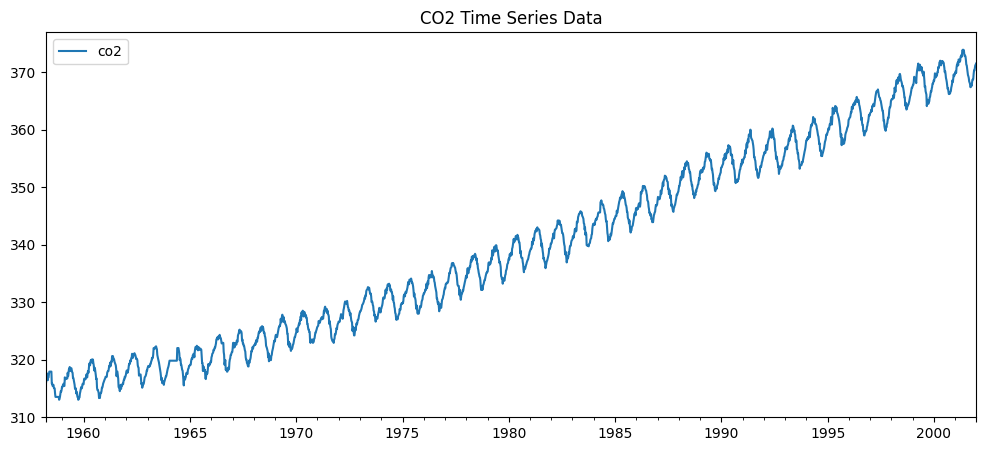

In [4]:
co2_df.plot(figsize=(12,5), title="CO2 Time Series Data")
plt.show()


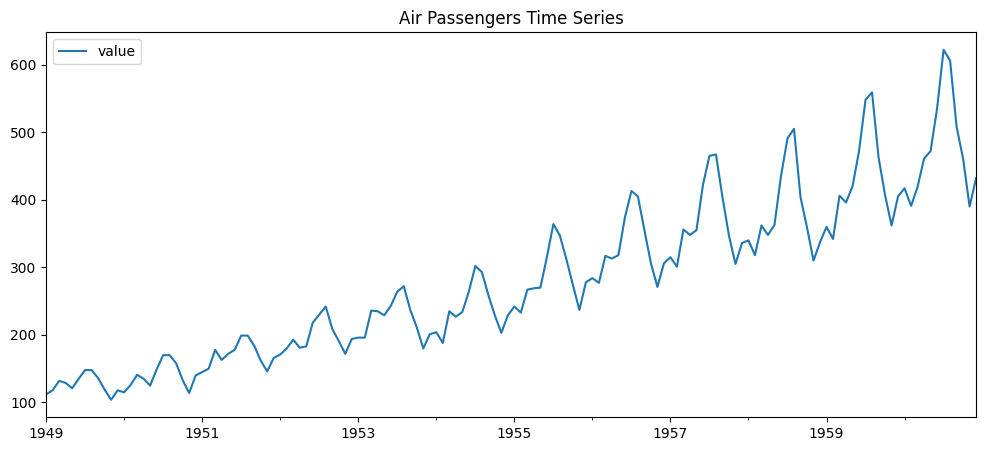

In [5]:
airp_df.plot(figsize=(12,5), title="Air Passengers Time Series")
plt.show()


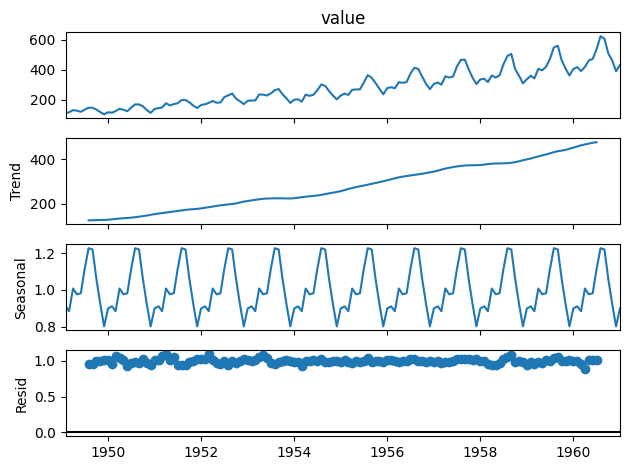

In [6]:
result = seasonal_decompose(airp_df['value'], model='multiplicative')

result.plot()
plt.show()


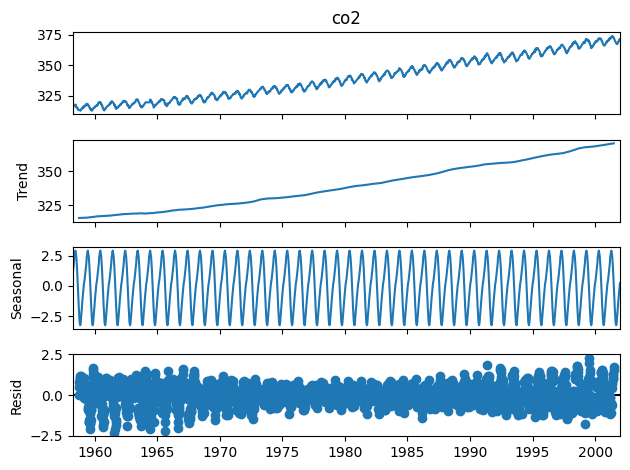

In [7]:
result2 = seasonal_decompose(co2_df['co2'], model='additive', period=52)

result2.plot()
plt.show()
